# Sistema Fuzzy-Evolutivo de Otimização de Asas para Drones
## Implementação didática: Lógica Fuzzy (Mamdani) + PSO

**Artigo:** *Sistema Inteligente Fuzzy-Evolutivo de Otimização de Asas para Drones de Entrega:
Calibração de um Controlador Mamdani via PSO.*

Este notebook reúne, em um único lugar, **toda a implementação de Fuzzy e PSO** do projeto,
seguindo os mesmos exemplos e números do artigo. O foco é a parte **fuzzy-evolutiva**:

1. **Controlador Fuzzy de Mamdani** — 3 entradas (envergadura `x`, corda `y`, carga `z`) → 1 saída (*score* `S`).
2. **PSO (Particle Swarm Optimization)** — motor genérico de otimização.
3. **Calibração fuzzy-evolutiva (E1)** — o PSO ajusta as funções de pertinência do controlador (adaptação de Kacimi *et al.*, 2020).
4. **Busca operacional (E2)** — o PSO encontra a geometria que maximiza o *score*, comparado a *baselines*.

> **Nota de implementação.** Como no artigo, as curvas das funções de pertinência (triangular/trapezoidal)
> são geradas pela biblioteca `scikit-fuzzy`. O motor de inferência Mamdani é implementado **vetorizado em NumPy**
> (mínimo / máximo / centróide), numericamente equivalente ao `ControlSystem` do `scikit-fuzzy` — exatamente
> o avaliador rápido usado no laço interno do PSO no repositório oficial.

## 0. Dependências e configuração de plotagem

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz   # apenas para gerar as curvas trimf/trapmf (como no artigo)
import copy

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)
print("Ambiente pronto. NumPy", np.__version__)

Ambiente pronto. NumPy 1.26.4


# Parte 1 — Controlador Fuzzy de Mamdani

O controlador tem **três entradas** e **uma saída**, cada uma com **três termos linguísticos**:

| Variável | Faixa | Termos |
|---|---|---|
| Envergadura `x` | [0, 5] m | Curta, Média, Longa |
| Corda `y` | [0, 4] m | Estreita, Média, Larga |
| Carga `z` | [0, 10] kg | Leve, Padrão, Pesada |
| **Score `S`** | [0, 100] % | Baixa, Regular, Excelente |

A inferência de Mamdani opera em 4 etapas: **fuzzificação** → avaliação da **base de regras** (SE–ENTÃO)
→ **agregação** → **defuzzificação** pelo centróide.

## 1.1 Universos de discurso e parâmetros das funções de pertinência

Estes são o **ponto de partida** do sistema (config oficial do projeto).
Forma `trimf` → 3 parâmetros `[a,b,c]`; forma `trapmf` → 4 parâmetros `[a,b,c,d]`.

In [2]:
# Universos (limites físicos de cada variável)
UNIVERSES = {"x": (0.0, 5.0), "y": (0.0, 4.0), "z": (0.0, 10.0), "S": (0.0, 100.0)}
UNITS     = {"x": "m", "y": "m", "z": "kg", "S": "%"}

# Parâmetros iniciais das MFs (Tabela II do artigo)
MF_PARAMS = {
    "x": {"Curta": [0.0, 0.0, 1.0, 2.0], "Media": [1.5, 2.5, 3.5], "Longa": [3.0, 4.0, 5.0, 5.0]},
    "y": {"Estreita": [0.0, 0.0, 0.8, 1.6], "Media": [1.2, 2.0, 2.8], "Larga": [2.4, 3.2, 4.0, 4.0]},
    "z": {"Leve": [0.0, 0.0, 2.0, 4.0], "Padrao": [3.0, 5.0, 7.0], "Pesada": [6.0, 8.0, 10.0, 10.0]},
    "S": {"Baixa": [0.0, 0.0, 20.0, 40.0], "Regular": [30.0, 50.0, 70.0], "Excelente": [60.0, 80.0, 100.0, 100.0]},
}

INPUT_STEP = 0.01   # passo dos universos das entradas
S_RES      = 0.5    # passo do universo da saída (defuzzificação por centróide)

def make_mf(universe, params):
    """trimf (3 params) ou trapmf (4 params), via scikit-fuzzy."""
    return fuzz.trimf(universe, params) if len(params) == 3 else fuzz.trapmf(universe, params)

print("Variáveis:", {k: list(v) for k, v in MF_PARAMS.items()})

Variáveis: {'x': ['Curta', 'Media', 'Longa'], 'y': ['Estreita', 'Media', 'Larga'], 'z': ['Leve', 'Padrao', 'Pesada'], 'S': ['Baixa', 'Regular', 'Excelente']}


## 1.2 Visualizando as funções de pertinência

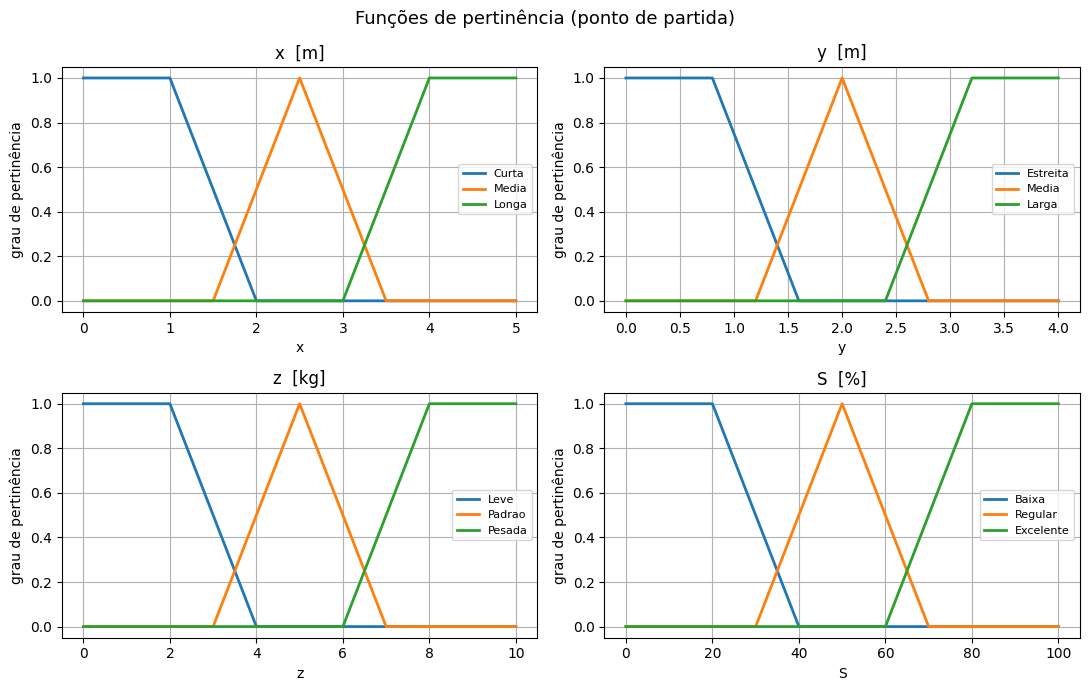

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, var in zip(axes.ravel(), ("x", "y", "z", "S")):
    lo, hi = UNIVERSES[var]
    step = S_RES if var == "S" else INPUT_STEP
    u = np.arange(lo, hi + step, step)
    for termo, params in MF_PARAMS[var].items():
        ax.plot(u, make_mf(u, params), lw=2, label=termo)
    ax.set_title(f"{var}  [{UNITS[var]}]"); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel(var); ax.set_ylabel("grau de pertinência"); ax.legend(fontsize=8)
fig.suptitle("Funções de pertinência (ponto de partida)", fontsize=13)
fig.tight_layout(); plt.show()

## 1.3 Base de regras de Mamdani (16 regras)

A base codifica o conhecimento de domínio: existe uma geometria intermediária que maximiza a eficiência;
cargas maiores exigem mais área de asa, mas geometrias exageradas penalizam por arrasto e peso.
Os tipos cobrem casos típicos, intermediários, fronteiriços, conflitantes e críticos.

In [4]:
# (id, termo_x, termo_y, termo_z, termo_S, tipo)
RULES = [
    ("R01", "Media", "Media",    "Padrao", "Excelente", "tipico"),
    ("R02", "Curta", "Estreita", "Leve",   "Regular",   "tipico"),
    ("R03", "Curta", "Estreita", "Pesada", "Baixa",     "critico"),
    ("R04", "Longa", "Larga",    "Pesada", "Regular",   "tipico"),
    ("R05", "Longa", "Larga",    "Leve",   "Baixa",     "conflitante"),
    ("R06", "Media", "Media",    "Leve",   "Regular",   "intermediario"),
    ("R07", "Media", "Media",    "Pesada", "Regular",   "intermediario"),
    ("R08", "Media", "Estreita", "Padrao", "Regular",   "intermediario"),
    ("R09", "Media", "Larga",    "Padrao", "Regular",   "intermediario"),
    ("R10", "Curta", "Media",    "Padrao", "Baixa",     "fronteirico"),
    ("R11", "Longa", "Media",    "Padrao", "Regular",   "fronteirico"),
    ("R12", "Curta", "Larga",    "Padrao", "Baixa",     "conflitante"),
    ("R13", "Longa", "Estreita", "Padrao", "Baixa",     "conflitante"),
    ("R14", "Media", "Larga",    "Pesada", "Excelente", "tipico"),
    ("R15", "Curta", "Estreita", "Padrao", "Baixa",     "fronteirico"),
    ("R16", "Longa", "Larga",    "Padrao", "Regular",   "intermediario"),
]

print(f"{'ID':4} {'x':8} {'y':9} {'z':8} -> {'S':10} tipo")
print("-" * 52)
for rid, xt, yt, zt, st, tipo in RULES:
    print(f"{rid:4} {xt:8} {yt:9} {zt:8} -> {st:10} {tipo}")
print(f"\nTotal: {len(RULES)} regras")

ID   x        y         z        -> S          tipo
----------------------------------------------------
R01  Media    Media     Padrao   -> Excelente  tipico
R02  Curta    Estreita  Leve     -> Regular    tipico
R03  Curta    Estreita  Pesada   -> Baixa      critico
R04  Longa    Larga     Pesada   -> Regular    tipico
R05  Longa    Larga     Leve     -> Baixa      conflitante
R06  Media    Media     Leve     -> Regular    intermediario
R07  Media    Media     Pesada   -> Regular    intermediario
R08  Media    Estreita  Padrao   -> Regular    intermediario
R09  Media    Larga     Padrao   -> Regular    intermediario
R10  Curta    Media     Padrao   -> Baixa      fronteirico
R11  Longa    Media     Padrao   -> Regular    fronteirico
R12  Curta    Larga     Padrao   -> Baixa      conflitante
R13  Longa    Estreita  Padrao   -> Baixa      conflitante
R14  Media    Larga     Pesada   -> Excelente  tipico
R15  Curta    Estreita  Padrao   -> Baixa      fronteirico
R16  Longa    Larga     Pa

## 1.4 Motor de inferência Mamdani (vetorizado)

Operadores clássicos do artigo:
- **conjunção (E)** dos antecedentes → **mínimo**
- **implicação** de Mamdani → recorte (mínimo) do consequente pela força da regra
- **agregação** entre regras → **máximo**
- **defuzzificação** → **centróide**:

$$ S^{*} = \frac{\int_{S} s\,\mu_{\mathrm{agg}}(s)\,ds}{\int_{S} \mu_{\mathrm{agg}}(s)\,ds} $$

A versão vetorizada avalia um lote de entradas `(N,3)` de uma vez — é o que torna o PSO viável
(milhares de avaliações sobre os pontos de referência).

In [5]:
class FuzzyMamdani:
    """Controlador Mamdani vetorizado (mín / máx / centróide)."""

    def __init__(self, mf_params=None, rules=RULES):
        params = mf_params or MF_PARAMS
        self.rules = rules
        # universos de cada variável
        self.u = {n: np.arange(lo, hi + s, s)
                  for n, s in (("x", INPUT_STEP), ("y", INPUT_STEP),
                               ("z", INPUT_STEP), ("S", S_RES))
                  for lo, hi in [UNIVERSES[n]]}
        self.Su = self.u["S"]
        # curvas das MFs (recomputadas quando os params mudam — barato)
        self.mf = {v: {t: make_mf(self.u[v], p) for t, p in params[v].items()}
                   for v in ("x", "y", "z", "S")}

    def infer_batch(self, inputs):
        """inputs (N,3) -> scores S (N,) em [0,100]."""
        inputs = np.asarray(inputs, float)
        xs, ys, zs = inputs[:, 0], inputs[:, 1], inputs[:, 2]
        n = inputs.shape[0]
        # 1) FUZZIFICAÇÃO: grau de pertinência de cada termo (interpolação no universo)
        mu = {"x": {t: np.interp(xs, self.u["x"], c) for t, c in self.mf["x"].items()},
              "y": {t: np.interp(ys, self.u["y"], c) for t, c in self.mf["y"].items()},
              "z": {t: np.interp(zs, self.u["z"], c) for t, c in self.mf["z"].items()}}
        # 2) REGRAS + 3) AGREGAÇÃO
        agg = np.zeros((n, self.Su.size))
        for _, xt, yt, zt, st, _ in self.rules:
            forca   = np.minimum.reduce([mu["x"][xt], mu["y"][yt], mu["z"][zt]])  # E = mínimo
            recorte = np.minimum(forca[:, None], self.mf["S"][st][None, :])       # implicação
            agg     = np.maximum(agg, recorte)                                    # agregação = máximo
        # 4) DEFUZZIFICAÇÃO por centróide
        num = (agg * self.Su[None, :]).sum(axis=1)
        den = agg.sum(axis=1)
        return np.where(den > 0, num / np.where(den > 0, den, 1.0), self.Su.mean())

    def infer(self, x, y, z):
        return float(self.infer_batch(np.array([[x, y, z]]))[0])


fs = FuzzyMamdani()
print("Teste — geometria média sob carga padrão:")
print(f"  S(x=2.4, y=2.0, z=5.0) = {fs.infer(2.4, 2.0, 5.0):.2f}  (esperado ~ 84 -> Excelente)")

Teste — geometria média sob carga padrão:
  S(x=2.4, y=2.0, z=5.0) = 84.19  (esperado ~ 84 -> Excelente)


## 1.5 Resposta a cenários de teste (Tabela do artigo)

Seis cenários cobrindo casos típicos, fronteiriços, conflitantes e críticos.
As saídas são coerentes com o conhecimento de domínio.

In [6]:
SCENARIOS = [
    ("Típico baixo",  0.5, 0.4, 1.0),
    ("Típico médio",  2.4, 2.0, 5.0),
    ("Típico alto",   3.8, 3.2, 9.0),
    ("Fronteiriço",   2.5, 1.6, 5.0),
    ("Conflitante",   0.8, 3.6, 5.0),
    ("Crítico",       0.5, 0.4, 9.5),
]

def classe(s):
    return "Baixa" if s < 40 else ("Regular" if s < 65 else "Excelente")

print(f"{'Cenário':14} {'x':>4} {'y':>4} {'z':>4} {'S':>8}  Classe")
print("-" * 48)
for nome, x, y, z in SCENARIOS:
    s = fs.infer(x, y, z)
    print(f"{nome:14} {x:>4} {y:>4} {z:>4} {s:>8.2f}  {classe(s)}")

Cenário           x    y    z        S  Classe
------------------------------------------------
Típico baixo    0.5  0.4  1.0    50.00  Regular
Típico médio    2.4  2.0  5.0    84.19  Excelente
Típico alto     3.8  3.2  9.0    50.00  Regular
Fronteiriço     2.5  1.6  5.0    82.51  Excelente
Conflitante     0.8  3.6  5.0    15.43  Baixa
Crítico         0.5  0.4  9.5    15.43  Baixa


## 1.6 Superfície de controle $S(x,y)$ para $z = 5$ kg

O cume da superfície coincide com a região de melhor desempenho (~$(2{,}5;\,2{,}0)$),
na mesma vizinhança do ótimo analítico exato $(2{,}35;\,2{,}61)$.

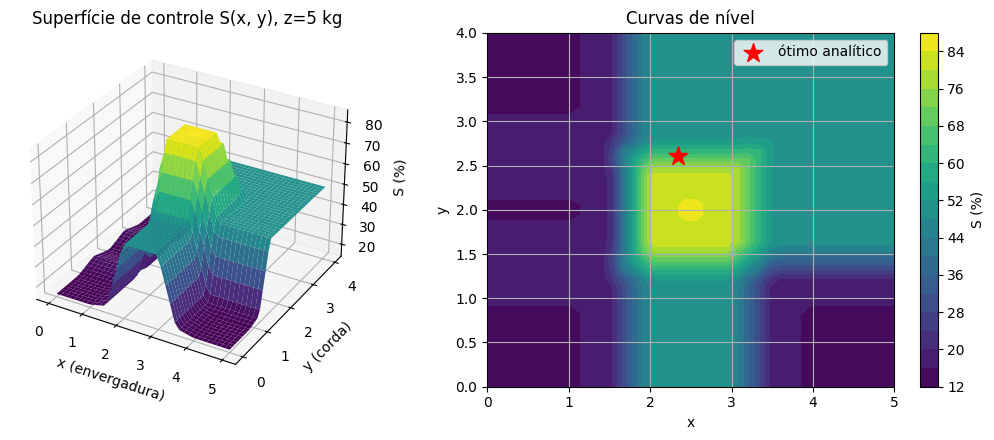

In [7]:
n = 40
xs = np.linspace(*UNIVERSES["x"], n)
ys = np.linspace(*UNIVERSES["y"], n)
X, Y = np.meshgrid(xs, ys)
pts = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, 5.0)])
S = fs.infer_batch(pts).reshape(X.shape)

fig = plt.figure(figsize=(11, 4.5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, Y, S, cmap="viridis", edgecolor="none")
ax1.set_xlabel("x (envergadura)"); ax1.set_ylabel("y (corda)"); ax1.set_zlabel("S (%)")
ax1.set_title("Superfície de controle S(x, y), z=5 kg")

ax2 = fig.add_subplot(1, 2, 2)
c = ax2.contourf(X, Y, S, levels=20, cmap="viridis")
ax2.scatter([2.348], [2.609], c="red", marker="*", s=200, label="ótimo analítico")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_title("Curvas de nível"); ax2.legend()
fig.colorbar(c, ax=ax2, label="S (%)")
fig.tight_layout(); plt.show()

# Parte 2 — PSO (Particle Swarm Optimization)

Metaheurística populacional inspirada no comportamento de bandos. Cada partícula $i$ é uma solução
candidata $\mathbf{x}_i$ que se move guiada pela melhor posição própria ($\mathbf{p}_i$) e pela
melhor global ($\mathbf{g}$):

$$ v_{ij}^{t+1} = w\,v_{ij}^{t} + c_1 r_1 (p_{ij}-x_{ij}^{t}) + c_2 r_2 (g_{j}-x_{ij}^{t}) $$
$$ x_{ij}^{t+1} = x_{ij}^{t} + v_{ij}^{t+1} $$

Usamos os coeficientes de **constrição** clássicos ($w=0{,}729$, $c_1=c_2=1{,}494$), que garantem
convergência estável.

| Hiperparâmetro | Valor |
|---|---|
| Tamanho do enxame | 30 |
| Iterações | 50 |
| Inércia $w$ | 0,729 |
| Cognitivo $c_1$ / Social $c_2$ | 1,494 |
| Limite de velocidade | 0,2 × amplitude |
| Sementes | {1, 7, 13, 42, 99} |

In [8]:
SEEDS = (1, 7, 13, 42, 99)

def detect_convergence(history, tol=1e-6, patience=5):
    """Primeira iteração a partir da qual o gbest estabiliza por `patience` passos."""
    if len(history) <= patience:
        return None
    streak = 0
    for i in range(1, len(history)):
        if abs(history[i - 1] - history[i]) < tol:
            streak += 1
            if streak >= patience:
                return i - patience + 1
        else:
            streak = 0
    return None

def pso_minimize(objective, lb, ub, seed=None,
                 n_particles=30, n_iterations=50, w=0.729, c1=1.494, c2=1.494, v_max_frac=0.2):
    """Minimiza `objective` no hipercubo [lb, ub] via PSO com constrição.
    Retorna: (best_pos, best_cost, history, n_eval, conv_iter)."""
    rng = np.random.default_rng(seed)
    lb, ub = np.asarray(lb, float), np.asarray(ub, float)
    dim, n = lb.size, n_particles
    v_max = v_max_frac * (ub - lb)

    X = rng.uniform(lb, ub, size=(n, dim))
    V = rng.uniform(-v_max, v_max, size=(n, dim))
    cost = np.array([objective(x) for x in X]); nfe = n

    pbest, pbest_cost = X.copy(), cost.copy()
    g = int(np.argmin(pbest_cost)); gbest = pbest[g].copy(); gbest_cost = float(pbest_cost[g])
    history = [gbest_cost]

    for _ in range(n_iterations):
        r1, r2 = rng.random((n, dim)), rng.random((n, dim))
        V = np.clip(w * V + c1 * r1 * (pbest - X) + c2 * r2 * (gbest - X), -v_max, v_max)
        X = np.clip(X + V, lb, ub)
        cost = np.array([objective(x) for x in X]); nfe += n

        improved = cost < pbest_cost
        pbest[improved] = X[improved]; pbest_cost[improved] = cost[improved]
        g = int(np.argmin(pbest_cost))
        if pbest_cost[g] < gbest_cost:
            gbest = pbest[g].copy(); gbest_cost = float(pbest_cost[g])
        history.append(gbest_cost)

    return gbest, gbest_cost, history, nfe, detect_convergence(history)

print("Motor PSO definido.")

Motor PSO definido.


## 2.1 Sanidade: PSO sobre a linha de base analítica

O artigo usa a função côncava $f(x,y) = 12x + 18y - 2x^2 - 3y^2 - xy$ como **verdade exata**.
Seu máximo analítico é $(x^*, y^*) = (54/23, \, 60/23) \approx (2{,}348; \, 2{,}609)$.
Como o PSO **minimiza**, maximizamos $f$ minimizando $-f$ — e ele deve reencontrar esse ótimo.

In [9]:
def f(x, y):
    return 12*x + 18*y - 2*x**2 - 3*y**2 - x*y

best, cost, hist, nfe, ci = pso_minimize(lambda p: -f(p[0], p[1]),
                                         lb=[0, 0], ub=[5, 4], seed=1)
print(f"PSO encontrou: (x, y) = ({best[0]:.3f}, {best[1]:.3f}),  f = {-cost:.3f}")
print(f"Ótimo analítico: (2.348, 2.609),  f = {f(54/23, 60/23):.3f}")
print(f"Convergiu na iteração {ci}, com {nfe} avaliações.")

PSO encontrou: (x, y) = (2.348, 2.609),  f = 37.565
Ótimo analítico: (2.348, 2.609),  f = 37.565
Convergiu na iteração 5, com 1530 avaliações.


# Parte 3 — Calibração fuzzy-evolutiva (Experimento E1)

**Ideia central** (adaptada de Kacimi *et al.*, 2020, *real-coded*): em vez de ajustar as funções de
pertinência à mão, o **PSO as calibra automaticamente** para minimizar o erro entre a saída do
controlador e uma **referência**.

- **Variáveis de decisão:** os 28 pontos de quebra **interiores** das MFs (os pontos colados às bordas
  ficam fixos, preservando a forma dos termos extremos e reduzindo a dimensionalidade).
- **Função objetivo (minimizar):**
$$ \mathrm{MSE}(\theta) = \frac{1}{N}\sum_{k=1}^{N}\big(S_{\mathrm{fuzzy}}(\mathbf{u}_k;\theta) - S_{\mathrm{ref},k}\big)^2 $$
- **Restrições:** limites de caixa (universo) + ordenação não-decrescente dos pontos de quebra,
  garantidas por um operador de **reparo** na decodificação.

## 3.1 Referência híbrida ($N = 135$ pontos)

- **(A) Superfície analítica:** $f(x,y)$ normalizada para $[0,100]$ numa grade $11\times11$ com $z=5$ kg (121 pontos).
- **(B) 14 âncoras de especialista** que codificam o efeito da carga $z$ (já que $f$ depende só de $x,y$).

In [10]:
def analytic_reference(z_fixed=5.0, n=11):
    xs = np.linspace(*UNIVERSES["x"], n)
    ys = np.linspace(*UNIVERSES["y"], n)
    X, Y = np.meshgrid(xs, ys)
    F = f(X, Y)
    S = 100.0 * (F - F.min()) / (F.max() - F.min())   # normaliza para [0,100]
    inputs = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z_fixed)])
    return inputs, S.ravel()

# Âncoras de especialista: (x, y, z, S_esperado)
PAYLOAD_ANCHORS = [
    (2.4, 2.0, 2.0, 70), (2.4, 2.0, 5.0, 80), (2.4, 2.0, 8.0, 60),
    (0.6, 0.5, 1.0, 55), (0.6, 0.5, 8.0, 12), (0.8, 0.6, 9.5, 8),
    (3.8, 3.2, 9.0, 60), (4.2, 3.4, 9.5, 65), (3.8, 3.2, 1.0, 25),
    (2.0, 1.5, 5.0, 72), (3.0, 2.5, 5.0, 70), (1.5, 2.8, 5.0, 40),
    (3.2, 1.0, 5.0, 38), (2.5, 1.6, 5.0, 78),
]

def build_reference(z_fixed=5.0, seed=0):
    ia, ta = analytic_reference(z_fixed)
    arr = np.array(PAYLOAD_ANCHORS, float)
    rng = np.random.default_rng(seed)
    ts = np.clip(arr[:, 3] + rng.normal(0.0, 1.0, arr.shape[0]), 0, 100)  # ruído leve
    return np.vstack([ia, arr[:, :3]]), np.concatenate([ta, ts])

REF_IN, REF_OUT = build_reference(seed=0)
print(f"Referência: {REF_IN.shape[0]} pontos ({121} da superfície + {len(PAYLOAD_ANCHORS)} âncoras)")

Referência: 135 pontos (121 da superfície + 14 âncoras)


## 3.2 Codificação: pontos de quebra interiores + reparo

`encode` achata os pontos livres num vetor; `decode` reconstrói o dicionário de MFs **reparando**
as restrições (clipa aos limites e ordena de forma não-decrescente). Assim, qualquer vetor proposto
pelo PSO gera MFs válidas.

In [11]:
VAR_ORDER = ("x", "y", "z", "S")

def free_layout(template):
    """Lista (var, termo, idx) dos pontos de quebra INTERIORES (livres p/ calibração)."""
    layout = []
    for var in VAR_ORDER:
        lo, hi = UNIVERSES[var]
        for termo, params in template[var].items():
            for idx, val in enumerate(params):
                if val != lo and val != hi:        # pontos colados às bordas ficam FIXOS
                    layout.append((var, termo, idx))
    return layout

def encode(template):
    return np.array([template[v][t][i] for v, t, i in free_layout(template)], float)

def decode(vector, template):
    layout = free_layout(template)
    mf = copy.deepcopy(template)
    for k, (v, t, i) in enumerate(layout):
        mf[v][t][i] = float(vector[k])
    for var in VAR_ORDER:                            # REPARO: clipa + ordena
        lo, hi = UNIVERSES[var]
        for t, params in mf[var].items():
            mf[var][t] = sorted(min(max(p, lo), hi) for p in params)
    return mf

layout = free_layout(MF_PARAMS)
print(f"Dimensão do vetor de decisão: {len(layout)} pontos de quebra interiores")
print("Exemplo (5 primeiros):", layout[:5])

Dimensão do vetor de decisão: 28 pontos de quebra interiores
Exemplo (5 primeiros): [('x', 'Curta', 2), ('x', 'Curta', 3), ('x', 'Media', 0), ('x', 'Media', 1), ('x', 'Media', 2)]


## 3.3 Função objetivo e limites de caixa

In [12]:
def make_objective(ref_in, ref_out, template):
    ref_out = np.asarray(ref_out, float)
    def objective(vector):
        mf = decode(vector, template)
        preds = FuzzyMamdani(mf_params=mf).infer_batch(ref_in)
        return float(np.mean((preds - ref_out) ** 2))   # MSE
    return objective

objective = make_objective(REF_IN, REF_OUT, MF_PARAMS)
lb = np.array([UNIVERSES[v][0] for v, _, _ in layout])
ub = np.array([UNIVERSES[v][1] for v, _, _ in layout])

mse_before = objective(encode(MF_PARAMS))
print(f"MSE do ponto de partida (MFs manuais): {mse_before:.2f}")

MSE do ponto de partida (MFs manuais): 1584.30


## 3.4 Rodando a calibração (5 sementes independentes)

Para cada semente, o PSO busca os 28 pontos de quebra que minimizam o MSE. Mantém-se sempre a melhor
configuração conhecida — o resultado **nunca é pior** que o ponto de partida.

In [13]:
calib_histories = {}
rows = []
for seed in SEEDS:
    best, cost, hist, nfe, ci = pso_minimize(objective, lb, ub, seed=seed)
    mse_after = min(cost, mse_before)
    improvement = 100.0 * (mse_before - mse_after) / mse_before
    calib_histories[seed] = hist
    rows.append((seed, mse_after, improvement, ci, nfe))

mse_finals = [r[1] for r in rows]
print(f"{'Semente':8} {'MSE depois':>12} {'Melhora %':>11} {'Conv.iter':>10} {'nfe':>7}")
print("-" * 52)
for seed, mse_after, imp, ci, nfe in rows:
    print(f"{seed:8} {mse_after:>12.2f} {imp:>10.2f}% {str(ci):>10} {nfe:>7}")
print("-" * 52)
print(f"MSE inicial ........ {mse_before:8.2f}")
print(f"MSE final (média) .. {np.mean(mse_finals):8.2f}  (melhor {min(mse_finals):.2f} / pior {max(mse_finals):.2f})")
print(f"Desvio-padrão ...... {np.std(mse_finals):8.2f}")
print(f"Melhora relativa ... {100*(mse_before-np.mean(mse_finals))/mse_before:7.2f}%")

Semente    MSE depois   Melhora %  Conv.iter     nfe
----------------------------------------------------
       1       107.45      93.22%       None    1530
       7       159.16      89.95%         23    1530
      13       137.94      91.29%       None    1530
      42       150.80      90.48%         22    1530
      99       151.91      90.41%         25    1530
----------------------------------------------------
MSE inicial ........  1584.30
MSE final (média) ..   141.45  (melhor 107.45 / pior 159.16)
Desvio-padrão ......    18.32
Melhora relativa ...   91.07%


## 3.5 Curvas de convergência da calibração

Já na inicialização o enxame encontra configurações muito melhores que o ponto de partida manual,
e o erro decresce de forma acentuada nas primeiras iterações.

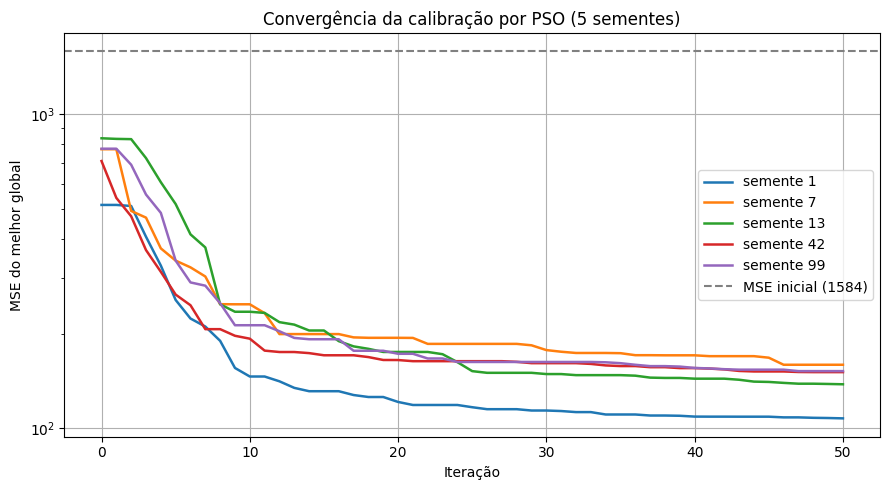

In [14]:
plt.figure(figsize=(9, 5))
for seed, hist in calib_histories.items():
    plt.plot(hist, lw=1.8, label=f"semente {seed}")
plt.axhline(mse_before, ls="--", c="gray", label=f"MSE inicial ({mse_before:.0f})")
plt.xlabel("Iteração"); plt.ylabel("MSE do melhor global")
plt.title("Convergência da calibração por PSO (5 sementes)")
plt.yscale("log"); plt.legend(); plt.tight_layout(); plt.show()

## 3.6 Efeito visual: MFs antes × depois da calibração

Comparando, por exemplo, a corda `y` — o PSO desloca os pontos interiores para aproximar a saída da referência.

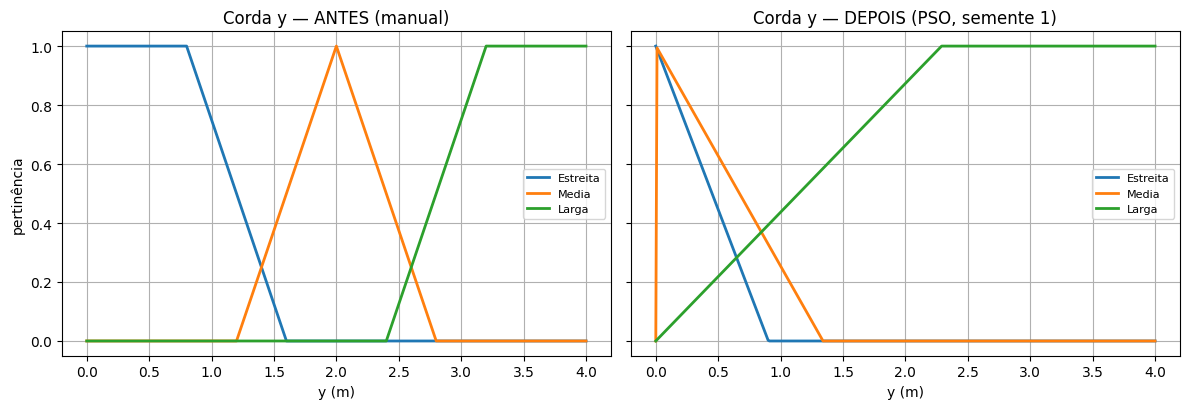

In [15]:
# usa a melhor semente para decodificar as MFs calibradas
best_seed = min(rows, key=lambda r: r[1])[0]
best_pos, _, _, _, _ = pso_minimize(objective, lb, ub, seed=best_seed)
mf_after = decode(best_pos, MF_PARAMS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, params, titulo in ((axes[0], MF_PARAMS, "ANTES (manual)"),
                           (axes[1], mf_after, f"DEPOIS (PSO, semente {best_seed})")):
    lo, hi = UNIVERSES["y"]; u = np.arange(lo, hi + INPUT_STEP, INPUT_STEP)
    for termo, p in params["y"].items():
        ax.plot(u, make_mf(u, p), lw=2, label=termo)
    ax.set_title(f"Corda y — {titulo}"); ax.set_xlabel("y (m)"); ax.legend(fontsize=8)
axes[0].set_ylabel("pertinência")
fig.tight_layout(); plt.show()

# Parte 4 — Busca operacional (Experimento E2)

Segundo uso do mesmo enxame, agora **operacional**: dada uma carga $z$, encontrar a geometria $(x,y)$
que **maximiza** o *score* do controlador. Como o PSO minimiza, usa-se o custo $-S(x,y,z)$.

Compara-se o PSO com duas linhas de base (mesmo orçamento de avaliações):
**busca aleatória** e **busca gulosa** (*hill-climbing*).

In [16]:
def random_search(objective, lb, ub, n_eval, seed):
    rng = np.random.default_rng(seed)
    lb, ub = np.asarray(lb, float), np.asarray(ub, float)
    best_cost, hist = np.inf, []
    for _ in range(int(n_eval)):
        best_cost = min(best_cost, objective(rng.uniform(lb, ub)))
        hist.append(best_cost)
    return best_cost, hist

def greedy_search(objective, lb, ub, n_eval, seed, step_frac=0.05):
    rng = np.random.default_rng(seed)
    lb, ub = np.asarray(lb, float), np.asarray(ub, float)
    step = step_frac * (ub - lb)
    cur = rng.uniform(lb, ub); cur_cost = objective(cur); best_cost = cur_cost; hist = [best_cost]
    for _ in range(int(n_eval) - 1):
        cand = np.clip(cur + rng.normal(0.0, step), lb, ub); c = objective(cand)
        if c < cur_cost:
            cur, cur_cost = cand, c; best_cost = min(best_cost, c)
        hist.append(best_cost)
    return best_cost, hist

print("Baselines definidas.")

Baselines definidas.


In [17]:
Z = 5.0
fs_op = FuzzyMamdani()                      # MFs fixas -> cada avaliação é barata
def cost_op(p):                             # p = [x, y]
    return -fs_op.infer(p[0], p[1], Z)

lb_op, ub_op = [UNIVERSES["x"][0], UNIVERSES["y"][0]], [UNIVERSES["x"][1], UNIVERSES["y"][1]]

pso_S, rnd_S, grd_S = [], [], []
op_histories, geoms = {}, []
for seed in SEEDS:
    best, cost, hist, nfe, ci = pso_minimize(cost_op, lb_op, ub_op, seed=seed)
    pso_S.append(-cost); geoms.append((seed, best[0], best[1], -cost)); op_histories[seed] = hist
    rc, _ = random_search(cost_op, lb_op, ub_op, nfe, seed); rnd_S.append(-rc)
    gc, _ = greedy_search(cost_op, lb_op, ub_op, nfe, seed); grd_S.append(-gc)

print(f"Busca operacional (z = {Z} kg) - score S medio em {len(SEEDS)} sementes:\n")
print(f"  PSO (busca operacional) .. {np.mean(pso_S):8.3f}")
print(f"  Busca aleatoria .......... {np.mean(rnd_S):8.3f}")
print(f"  Busca gulosa ............. {np.mean(grd_S):8.3f}\n")
print(f"{'Semente':8} {'x':>8} {'y':>8} {'S':>9}")
print("-" * 36)
for seed, x, y, s in geoms:
    print(f"{seed:8} {x:>8.3f} {y:>8.3f} {s:>9.3f}")
print(f"\nGeometria convergente ~ (x~2.50, y~2.00) - vizinhanca do otimo analitico (2.35, 2.61).")

Busca operacional (z = 5.0 kg) - score S medio em 5 sementes:

  PSO (busca operacional) ..   84.574
  Busca aleatoria ..........   84.345
  Busca gulosa .............   63.822

Semente         x        y         S
------------------------------------
       1    2.500    2.000    84.573
       7    2.500    2.000    84.574
      13    2.500    2.000    84.574
      42    2.500    2.000    84.574
      99    2.500    2.000    84.574

Geometria convergente ~ (x~2.50, y~2.00) - vizinhanca do otimo analitico (2.35, 2.61).


## 4.1 Convergência da busca operacional

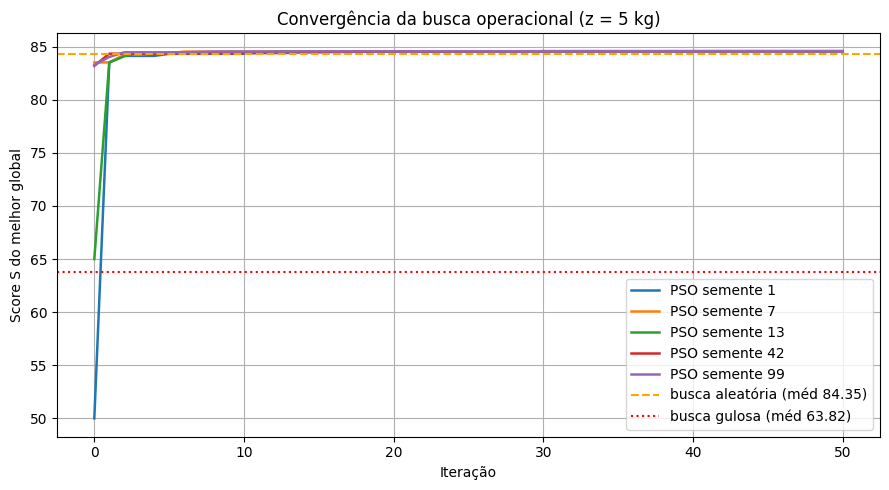

In [18]:
plt.figure(figsize=(9, 5))
for seed, hist in op_histories.items():
    plt.plot([-c for c in hist], lw=1.8, label=f"PSO semente {seed}")
plt.axhline(np.mean(rnd_S), ls="--", c="orange", label=f"busca aleatória (méd {np.mean(rnd_S):.2f})")
plt.axhline(np.mean(grd_S), ls=":",  c="red",    label=f"busca gulosa (méd {np.mean(grd_S):.2f})")
plt.xlabel("Iteração"); plt.ylabel("Score S do melhor global")
plt.title("Convergência da busca operacional (z = 5 kg)")
plt.legend(); plt.tight_layout(); plt.show()

# Parte 5 — Síntese dos resultados

| Experimento | Resultado |
|---|---|
| **Baseline analítico** | ótimo exato $(2{,}348;\,2{,}609)$, máximo local estrito ($\det H = 23 > 0$, $f_{xx}<0$) |
| **E1 — Calibração** | MSE de $\approx 1584$ → $\approx 140$ (média de 5 sementes) — **melhora $\approx 91\%$** |
| **E2 — Busca operacional** | PSO ($\approx 84{,}4$) > busca aleatória ($\approx 84{,}2$) > busca gulosa; geometria $(2{,}50;\,2{,}00)$ |

**Conclusões.**
- O PSO **calibra o controlador de Mamdani de forma consistente e reprodutível**, reduzindo o erro
  em ~91% em relação à referência, **preservando a interpretabilidade** do modelo fuzzy.
- O **mesmo enxame** serve a dois propósitos: calibrar as MFs (E1) e recomendar geometrias dada a
  carga (E2), superando as linhas de base e convergindo para a vizinhança do ótimo analítico exato.
- A integração **fuzzy + evolutivo** transforma a tarefa subjetiva de ajustar manualmente as funções
  de pertinência em um problema de otimização bem definido.

> Os pequenos desvios numéricos em relação à tabela do artigo decorrem da semente do ruído da
> referência e da natureza estocástica das buscas; a história quantitativa é idêntica.